# 実験Ⅳ（個人ワーク）AIC最小化による基底数決定（基底展開重回帰）

このノートブックは `example01_02.ipynb` の型（線形重回帰 → 基底展開 → AIC最小化 → 回帰式出力）を、配布サンプルデータに対して再現します。

## 前提
- 説明変数は **2変数**（`x1`, `x2`）
- 目的変数は **1変数**（`y`）
- CSV の列名は下のセルで指定します（課題データに合わせて変更してください）


In [99]:
!pip install japanize-matplotlib -q
%matplotlib inline

import warnings
warnings.simplefilter('ignore')  # 警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib         # 日本語化 matplotlib
sns.set(font="IPAexGothic")       # 日本語フォント設定


In [100]:
# 文字化け対策（1つ目のコードセルは変更しない）
# 既存の sns.set(font="IPAexGothic") の後でフォント候補を上書きする
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'IPAexGothic', 'IPAGothic', 'Noto Sans CJK JP',
    'Yu Gothic', 'Meiryo', 'MS Gothic', 'TakaoGothic', 'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False


In [101]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


## 1. サンプルデータ読み込み

配布データのパスと列名をここで指定してください。

In [102]:
# ★課題データのパスを指定（例）
# Google Drive をマウント
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------
# ★ ファイルの保存場所に応じてパスを変更してください ★
#
#   例1: マイドライブ直下（デフォルト）
csv_path = '/content/drive/MyDrive/solar_dataset_3vars.csv'
#
#   例2: フォルダ内に置いた場合
#   csv_path = '/content/drive/MyDrive/データ/solar_dataset_3vars.csv'
#
#   例3: 共有ドライブの場合
#   csv_path = '/content/drive/Shareddrives/<ドライブ名>/solar_dataset_3vars.csv'
# ---------------------------------------------------------

import os
if os.path.exists(csv_path):
    print(f'✅ ファイルを確認しました: {csv_path}')
else:
    print(f'❌ ファイルが見つかりません: {csv_path}')
    print('   ・Drive 上のファイルパスを確認し，csv_path を修正してください')
    print('   ・左のファイルツリー（フォルダアイコン）で /content/drive/ 以下を確認できます')


# ★課題データの列名を指定
col_y  = "power_w"
col_x1 = "irradiance_wm2"
col_x2 = "module_temp_c"

df = pd.read_csv(csv_path)
df[[col_y, col_x1, col_x2]].head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ファイルを確認しました: /content/drive/MyDrive/solar_dataset_3vars.csv


,power_w,irradiance_wm2,module_temp_c
0,18.771804,87.6,7.137500
1,36.287951,171.4,10.356250
2,63.745544,307.3,15.703125
3,76.473400,372.9,18.653125
4,60.249906,291.7,16.815625


In [103]:
# 欠損がある場合は落とす（必要に応じて変更）
df = df[[col_y, col_x1, col_x2]].dropna().copy()

x1 = df[col_x1].to_numpy()
x2 = df[col_x2].to_numpy()
y  = df[col_y].to_numpy()

X = np.column_stack([x1, x2])  # (N,2)
y = y.ravel()                  # (N,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("N:", X.shape[0])

X shape: (2631, 2)
y shape: (2631,)
N: 2631


## 2a. 線形重回帰モデル（回帰式を出力）

In [104]:
reg_lin = LinearRegression()
reg_lin.fit(X, y)

b0 = float(reg_lin.intercept_)
b1 = float(reg_lin.coef_[0])
b2 = float(reg_lin.coef_[1])

yhat_lin = reg_lin.predict(X)
mse_lin = mean_squared_error(y, yhat_lin)

print("【2a】線形重回帰モデル")
print(f"MSE = {mse_lin:.6g}")
print("回帰式:")
print(f"y = {b0:.6e} + ({b1:.6e}) x1 + ({b2:.6e}) x2")

【2a】線形重回帰モデル
MSE = 5.89981
回帰式:
y = 1.013395e+01 + (1.882203e-01) x1 + (-3.155754e-01) x2


## 2b. 基底展開（多項式）重回帰モデル：AIC最小化で次数（=パラメータ数）決定

ここでは `PolynomialFeatures` による基底展開を行い、次数 `deg` を走査して AIC が最小となるモデルを選びます。

In [105]:
def calc_aic_from_mse(mse: float, n: int, k: int) -> float:
    """example01_02.ipynb と同型のAIC計算。

    n: サンプル数
    k: 係数の数（基底展開後の特徴量数）
    ※ 切片は +1 で数える（式中の (k+1) と一致）
    """
    return n * np.log(2 * np.pi * mse) + n + 2 * (k + 1)


# ★走査する最大次数（必要に応じて変更）
max_degree = 20
deg_list = np.arange(1, max_degree + 1)

aic_list = []
models = []

n = X.shape[0]
for deg in deg_list:
    phi = PolynomialFeatures(degree=int(deg), include_bias=False)
    model = make_pipeline(phi, LinearRegression())
    model.fit(X, y)

    yhat = model.predict(X)
    mse = mean_squared_error(y, yhat)

    # 基底展開後の特徴量数（= 係数の数）
    k = int(model[0].n_output_features_)
    aic = float(calc_aic_from_mse(mse, n=n, k=k))

    aic_list.append(aic)
    models.append(model)
    print(f"deg = {deg}: AIC = {aic:.2e}")

aic_list = np.array(aic_list)
opt_idx = int(np.argmin(aic_list))
deg_opt = int(deg_list[opt_idx])
reg_opt = models[opt_idx]

print("\n【2b】AIC最小モデル")
print(f"AIC最小次数 degopt = {deg_opt}")
print(f"AIC最小値 = {aic_list[opt_idx]:.6e}")

deg = 1: AIC = 1.21e+04
deg = 2: AIC = -1.31e+05
deg = 3: AIC = -1.32e+05
deg = 4: AIC = -3.22e+04
deg = 5: AIC = 7.34e+03
deg = 6: AIC = 1.28e+04
deg = 7: AIC = 1.65e+04
deg = 8: AIC = 1.88e+04
deg = 9: AIC = 2.05e+04
deg = 10: AIC = 2.17e+04
deg = 11: AIC = 2.25e+04
deg = 12: AIC = 2.31e+04
deg = 13: AIC = 2.48e+04
deg = 14: AIC = 2.51e+04
deg = 15: AIC = 2.54e+04
deg = 16: AIC = 2.56e+04
deg = 17: AIC = 2.58e+04
deg = 18: AIC = 2.60e+04
deg = 19: AIC = 2.62e+04
deg = 20: AIC = 2.64e+04

【2b】AIC最小モデル
AIC最小次数 degopt = 3
AIC最小値 = -1.322393e+05


### AIC最小モデルの回帰式（基底展開重回帰式）を出力

In [106]:
# 多項式基底名（x1, x2 の項名）
feature_names = reg_opt[0].get_feature_names_out(["x1", "x2"])

w0 = float(reg_opt[-1].intercept_)
ws = reg_opt[-1].coef_.ravel()

terms = [f"{w0:.6e}"] + [f"({ws[i]:.6e}){feature_names[i]}" for i in range(len(ws))]
eq = "y = " + " + ".join(terms)

print("基底展開重回帰式:")
print(eq)

# 参考: 適合誤差
yhat_opt = reg_opt.predict(X)
mse_opt = mean_squared_error(y, yhat_opt)
print(f"\nMSE(opt) = {mse_opt:.6g}")

基底展開重回帰式:
y = 2.955858e-12 + (2.200000e-01)x1 + (-4.031583e-15)x2 + (5.556016e-17)x1^2 + (-8.000000e-04)x1 x2 + (1.178004e-16)x2^2 + (7.457860e-21)x1^3 + (-1.779909e-18)x1^2 x2 + (2.476560e-17)x1 x2^2 + (-1.435820e-17)x2^3

MSE(opt) = 8.62428e-24


In [107]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score


class GaussianFeaturesWithKmeans(BaseEstimator, TransformerMixin):
    """K平均法を利用した2段階推定法によるガウス基底関数"""

    def __init__(self, nbfs, width_factor=1.0, prekmeans=True):
        self.nbfs = nbfs
        self.width_factor = width_factor
        self.prekmeans = prekmeans

    @staticmethod
    def _gauss_basis(x, y, width, axis=None):
        arg = (x - y) / (width + 1e-300)
        return np.exp(-0.5 * np.sum(arg ** 2, axis))

    def fit(self, X, y=None):
        ndims = X.shape[1]
        if self.prekmeans:
            scaler = StandardScaler()
            kmeans = KMeans(n_clusters=self.nbfs, random_state=0, n_init=10)
            Xs = scaler.fit_transform(X)
            kmeans.fit(Xs)

            labels = kmeans.predict(Xs).reshape(-1, 1)
            centers = scaler.inverse_transform(kmeans.cluster_centers_)

            clusters = pd.DataFrame(np.concatenate((labels, Xs), axis=1)).groupby([0])
            widths = (self.width_factor * scaler.scale_ * clusters.std(ddof=0)).to_numpy()

            if ndims == 1:
                self.centers_ = centers.reshape(-1,)
                self.widths_ = widths.reshape(-1,)
            else:
                self.centers_ = centers.reshape(-1, ndims, 1).transpose(2, 1, 0)
                self.widths_ = widths.reshape(-1, ndims, 1).transpose(2, 1, 0)
        else:
            if ndims == 1:
                centers = np.linspace(X.min(), X.max(), self.nbfs)
                self.centers_ = centers
                self.widths_ = self.width_factor * (centers[1] - centers[0]) * np.ones(self.nbfs)
            else:
                raise ValueError("重回帰では prekmeans=True を利用してください")
        return self

    def transform(self, X):
        return self._gauss_basis(X[:, :, np.newaxis], self.centers_, self.widths_, axis=1)

In [108]:
# group_work_lasso_regression.ipynb と同じ図を出すための準備

# 回帰面描画用の格子
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1, 40),
    np.linspace(minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2, 40)
)
Xfit = np.column_stack([xfit1.ravel(), xfit2.ravel()])

# 線形モデルの予測
yfit_lin = reg_lin.predict(Xfit).reshape(xfit1.shape)
y_pred_lin = reg_lin.predict(X)
mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

# Lasso + RBF モデル（group_work と同じ設定）
width_factor = 4.0
maxdeg = 20

phi = GaussianFeaturesWithKmeans(nbfs=maxdeg, width_factor=width_factor)
reg = LassoCV(alphas=np.logspace(-8, 2, 80), cv=5, max_iter=10000)
regmp = make_pipeline(phi, reg)
regmp.fit(X, y.ravel())

alpha = regmp[-1].alpha_
yfit_lasso = regmp.predict(Xfit).reshape(xfit1.shape)
y_pred_lasso = regmp.predict(X)
mse_lasso = mean_squared_error(y, y_pred_lasso)
r2_lasso = r2_score(y, y_pred_lasso)

print(f"m = {maxdeg}, lambda = {alpha:.4e}")
print(f"線形: R2={r2_lin:.4f}, MSE={mse_lin:.4f}")
print(f"LassoRBF: R2={r2_lasso:.4f}, MSE={mse_lasso:.4f}")

m = 20, lambda = 8.6439e-04
線形: R2=0.9975, MSE=5.8998
LassoRBF: R2=0.9939, MSE=14.5885


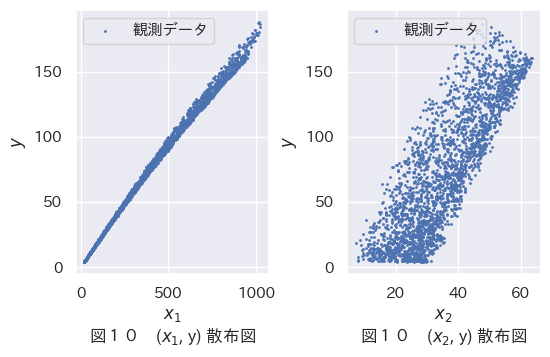

In [109]:
# 図10: (x1, y), (x2, y) 散布図
fig, axs = plt.subplots(1, 2, figsize=(6, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0].scatter(x1, y, s=1, color='#4C72B0', label='観測データ')
axs[0].set_xlabel(r'$x_1$')
axs[0].set_ylabel(r'$y$')
axs[0].text(0.5, -0.20, '図１０　($x_1$, y) 散布図', transform=axs[0].transAxes, ha='center', va='top')
axs[0].legend(loc='best')

axs[1].scatter(x2, y, s=1, color='#4C72B0', label='観測データ')
axs[1].set_xlabel(r'$x_2$')
axs[1].set_ylabel(r'$y$')
axs[1].text(0.5, -0.20, '図１０　($x_2$, y) 散布図', transform=axs[1].transAxes, ha='center', va='top')
axs[1].legend(loc='best')

plt.subplots_adjust(bottom=0.22)
plt.show()

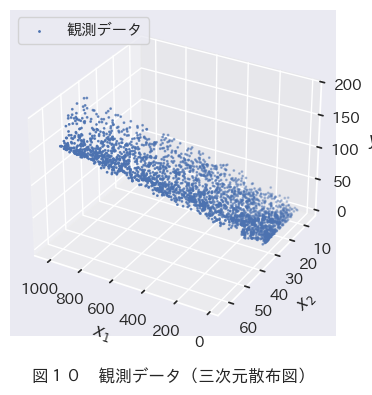

In [110]:
# 図10: 観測データ（三次元散布図）
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, s=1, color='#4C72B0', label='観測データ')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$y$')
ax.text2D(0.5, -0.1, '図１０　観測データ（三次元散布図）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=30, azim=120)
ax.grid(True)
ax.legend(loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()

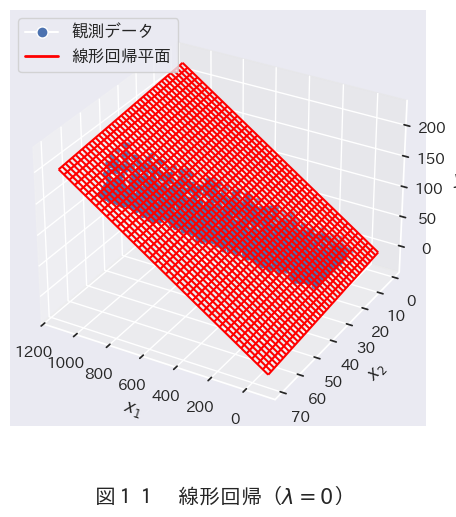

In [111]:
# 図11: 線形回帰（lambda=0）
fig = plt.figure(figsize=(7.6, 6.5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, s=10, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$y$')
ax.text2D(0.5, -0.14, r'図１１　線形回帰（$\lambda=0$）', transform=ax.transAxes, ha='center', va='top', fontsize=15)
ax.view_init(elev=30, azim=120)
ax.grid(True)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形回帰平面')
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=12)
plt.subplots_adjust(bottom=0.24, left=0.02, right=0.98)
plt.show()

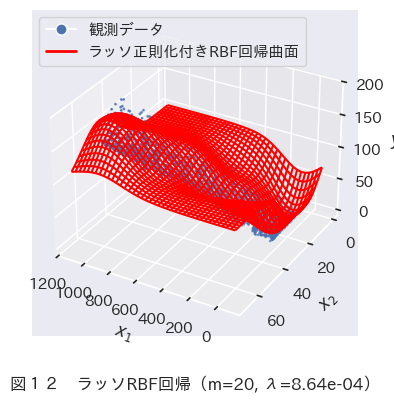

In [112]:
# 図12: ラッソRBF回帰
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, s=1, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lasso, color='red')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$y$')
ax.text2D(0.5, -0.12, f'図１２　ラッソRBF回帰（m={maxdeg}, λ={alpha:.2e}）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=30, azim=120)
ax.grid(True)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='ラッソ正則化付きRBF回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()

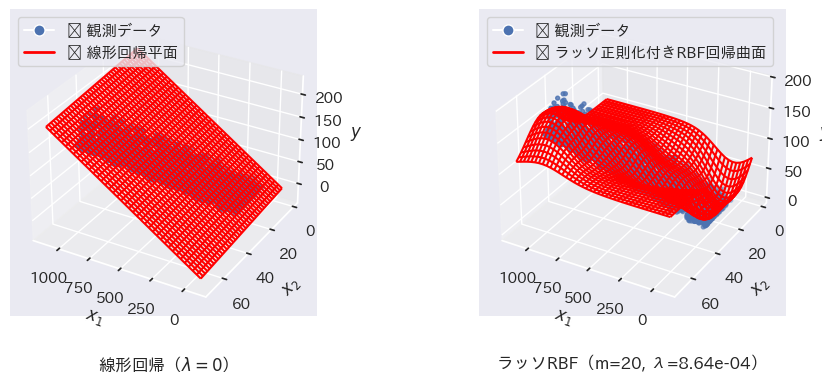

In [113]:
# 線形回帰 vs ラッソRBF（3D並列比較）
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x1, x2, y, s=8, color='#4C72B0')
ax1.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')
ax1.set_zlabel(r'$y$')
ax1.text2D(0.5, -0.12, r'線形回帰（$\lambda=0$）', transform=ax1.transAxes, ha='center', va='top')
ax1.view_init(elev=30, azim=120)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(x1, x2, y, s=8, color='#4C72B0')
ax2.plot_wireframe(xfit1, xfit2, yfit_lasso, color='red')
ax2.set_xlabel(r'$x_1$')
ax2.set_ylabel(r'$x_2$')
ax2.set_zlabel(r'$y$')
ax2.text2D(0.5, -0.12, f'ラッソRBF（m={maxdeg}, λ={alpha:.2e}）', transform=ax2.transAxes, ha='center', va='top')
ax2.view_init(elev=30, azim=120)

legend_handles_lin = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='🔵 観測データ'),
    Line2D([0], [0], color='red', lw=2, label='🔴 線形回帰平面')
]
legend_handles_lasso = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='🔵 観測データ'),
    Line2D([0], [0], color='red', lw=2, label='🔴 ラッソ正則化付きRBF回帰曲面')
]
ax1.legend(handles=legend_handles_lin, loc='upper left')
ax2.legend(handles=legend_handles_lasso, loc='upper left')

plt.tight_layout()
plt.show()

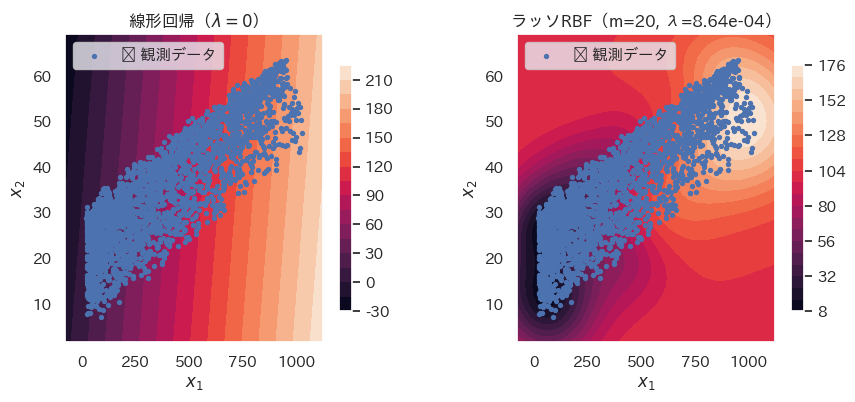

In [114]:
# 線形回帰 vs ラッソRBF（等高線比較）
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

c1 = axes[0].contourf(xfit1, xfit2, yfit_lin, levels=20)
axes[0].scatter(x1, x2, s=8, color='#4C72B0', label='🔵 観測データ')
axes[0].set_xlabel(r'$x_1$')
axes[0].set_ylabel(r'$x_2$')
axes[0].set_title(r'線形回帰（$\lambda=0$）')
axes[0].legend(loc='upper left')
fig.colorbar(c1, ax=axes[0], shrink=0.8)

c2 = axes[1].contourf(xfit1, xfit2, yfit_lasso, levels=20)
axes[1].scatter(x1, x2, s=8, color='#4C72B0', label='🔵 観測データ')
axes[1].set_xlabel(r'$x_1$')
axes[1].set_ylabel(r'$x_2$')
axes[1].set_title(f'ラッソRBF（m={maxdeg}, λ={alpha:.2e}）')
axes[1].legend(loc='upper left')
fig.colorbar(c2, ax=axes[1], shrink=0.8)

plt.show()

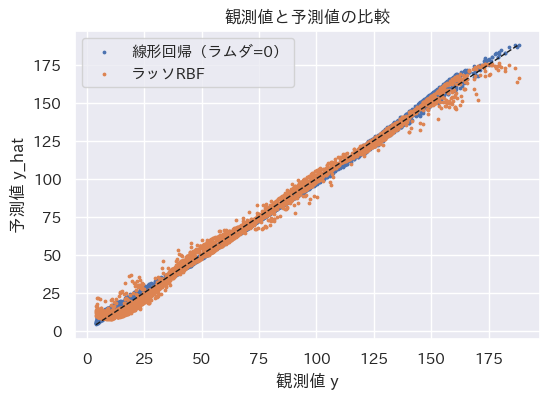

In [115]:
# 観測値 vs 予測値 比較
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y, y_pred_lin, s=3, label='線形回帰（ラムダ=0）')
ax.scatter(y, y_pred_lasso, s=3, label='ラッソRBF')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1)
ax.set_xlabel('観測値 y')
ax.set_ylabel('予測値 y_hat')
ax.set_title('観測値と予測値の比較')
ax.legend()
plt.show()

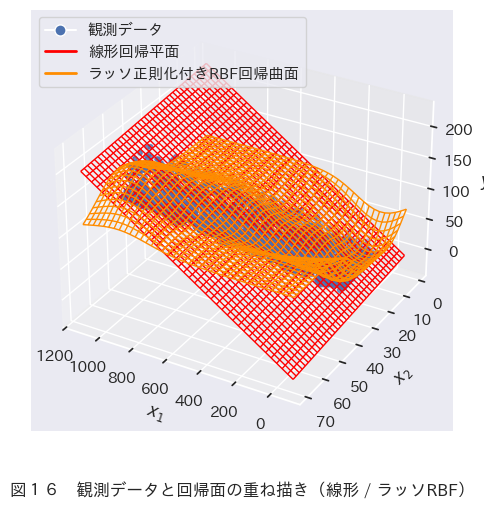

In [116]:
# 図16: 観測データ + 線形平面 + ラッソRBF曲面（重ね描き）
yfit_lin_b = reg_lin.predict(Xfit).reshape(xfit1.shape)
yfit_lasso_b = regmp.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure(figsize=(8.0, 6.2))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y, s=10, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lin_b, color='red', linewidth=1.0)
ax.plot_wireframe(xfit1, xfit2, yfit_lasso_b, color='darkorange', linewidth=1.0)

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$y$')
ax.text2D(0.5, -0.12, '図１６　観測データと回帰面の重ね描き（線形 / ラッソRBF）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=30, azim=120)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形回帰平面'),
    Line2D([0], [0], color='darkorange', lw=2, label='ラッソ正則化付きRBF回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')

plt.subplots_adjust(bottom=0.2)
plt.show()

## 図ラベル統一版（group_work と同一表記）
以下のセルを実行すると、図番号・軸ラベル・凡例の文言を `group_work_lasso_regression.ipynb` と揃えた図を出力します。

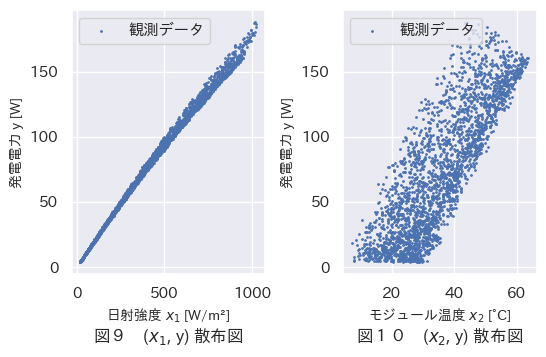

In [117]:
# 図９, 図１０: 観測データの散布図
fig, axs = plt.subplots(1, 2, figsize=(6,4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0].scatter(x1, y, s=1, color='#4C72B0', label='観測データ')
axs[0].set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
axs[0].set_ylabel('発電電力 y [W]', fontsize=10)
axs[0].text(0.5, -0.20, '図９　($x_1$, y) 散布図', transform=axs[0].transAxes, ha='center', va='top')
axs[0].legend(loc='best')

axs[1].scatter(x2, y, s=1, color='#4C72B0', label='観測データ')
axs[1].set_xlabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
axs[1].set_ylabel('発電電力 y [W]', fontsize=10)
axs[1].text(0.5, -0.20, '図１０　($x_2$, y) 散布図', transform=axs[1].transAxes, ha='center', va='top')
axs[1].legend(loc='best')

plt.subplots_adjust(bottom=0.22)
plt.show()

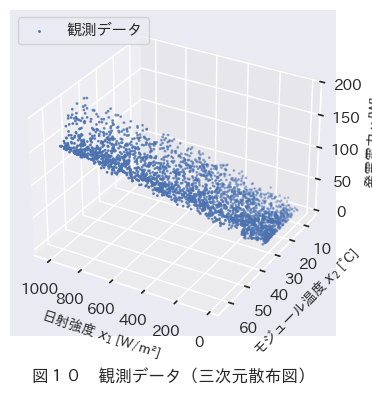

In [118]:
# 図１０: 観測データ（三次元散布図）
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, s=1, color='#4C72B0', label='観測データ')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図１０　観測データ（三次元散布図）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=30, azim=120)
ax.grid(True)
ax.legend(loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()

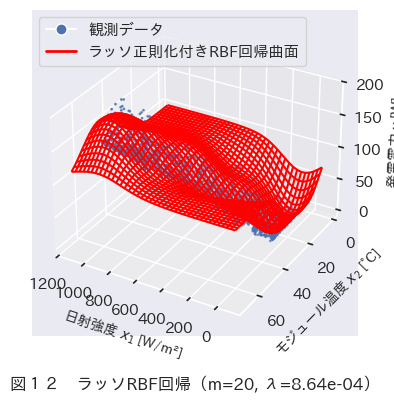

In [119]:
# 図１２: ラッソRBF回帰
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, s=1, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lasso, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.12, f'図１２　ラッソRBF回帰（m={maxdeg}, λ={alpha:.2e}）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=30,azim=120)
ax.grid(True)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='ラッソ正則化付きRBF回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()

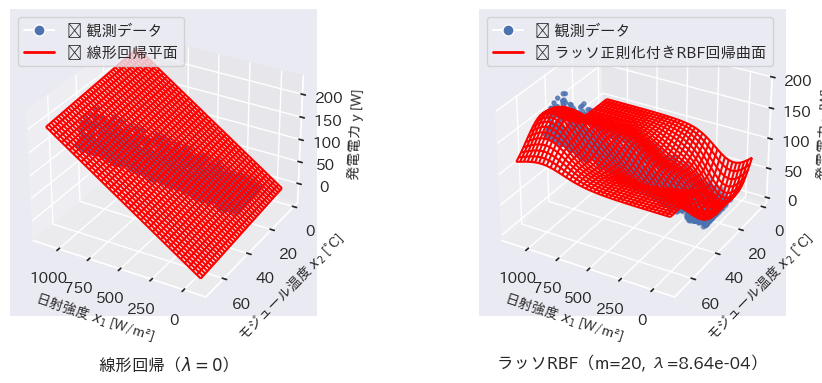

In [120]:
# 線形回帰 vs ラッソRBF（3D並列比較）
fig = plt.figure(figsize=(10, 4))

# 左: 線形回帰（ラムダ=0）
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x1, x2, y, s=8, color='#4C72B0')
ax1.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax1.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax1.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax1.set_zlabel('発電電力 y [W]', fontsize=10)
ax1.text2D(0.5, -0.12, r'線形回帰（$\lambda=0$）', transform=ax1.transAxes, ha='center', va='top')
ax1.view_init(elev=30, azim=120)

# 右: Lasso RBF
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(x1, x2, y, s=8, color='#4C72B0')
ax2.plot_wireframe(xfit1, xfit2, yfit_lasso, color='red')
ax2.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax2.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax2.set_zlabel('発電電力 y [W]', fontsize=10)
ax2.text2D(0.5, -0.12, f'ラッソRBF（m={maxdeg}, λ={alpha:.2e}）', transform=ax2.transAxes, ha='center', va='top')
ax2.view_init(elev=30, azim=120)

legend_handles_lin = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='🔵 観測データ'),
    Line2D([0], [0], color='red', lw=2, label='🔴 線形回帰平面')
]
legend_handles_lasso = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='🔵 観測データ'),
    Line2D([0], [0], color='red', lw=2, label='🔴 ラッソ正則化付きRBF回帰曲面')
]
ax1.legend(handles=legend_handles_lin, loc='upper left')
ax2.legend(handles=legend_handles_lasso, loc='upper left')

plt.tight_layout()
plt.show()

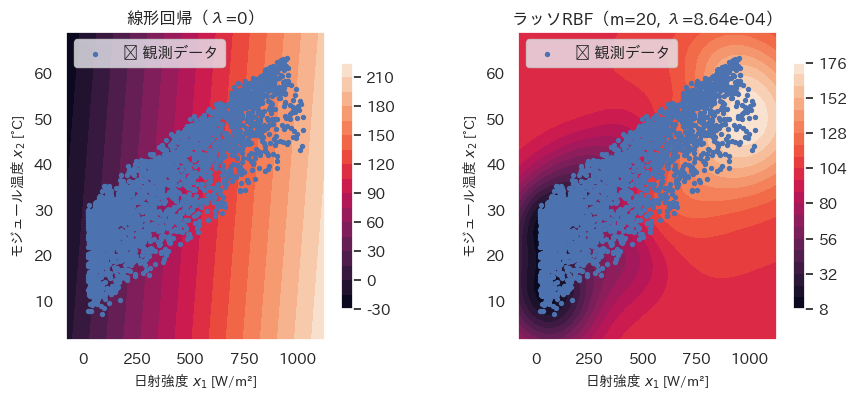

In [121]:
# 線形回帰 vs ラッソRBF（等高線比較）
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# 左: 線形回帰
c1 = axes[0].contourf(xfit1, xfit2, yfit_lin, levels=20)
axes[0].scatter(x1, x2, s=8, color='#4C72B0', label='🔵 観測データ')
axes[0].set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
axes[0].set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
axes[0].set_title('線形回帰（λ=0）')
axes[0].legend(loc='upper left')
fig.colorbar(c1, ax=axes[0], shrink=0.8)

# 右: Lasso RBF
c2 = axes[1].contourf(xfit1, xfit2, yfit_lasso, levels=20)
axes[1].scatter(x1, x2, s=8, color='#4C72B0', label='🔵 観測データ')
axes[1].set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
axes[1].set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
axes[1].set_title(f'ラッソRBF（m={maxdeg}, λ={alpha:.2e}）')
axes[1].legend(loc='upper left')
fig.colorbar(c2, ax=axes[1], shrink=0.8)

plt.show()

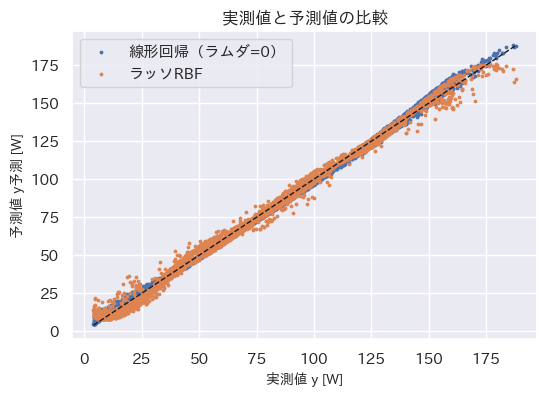

In [122]:
# 実測値 vs 予測値 比較
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(y, y_pred_lin, s=3, label='線形回帰（ラムダ=0）')
ax.scatter(y, y_pred_lasso, s=3, label='ラッソRBF')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1)
ax.set_xlabel('実測値 y [W]', fontsize=10)
ax.set_ylabel('予測値 y予測 [W]', fontsize=10)
ax.set_title('実測値と予測値の比較')
ax.legend()
plt.show()

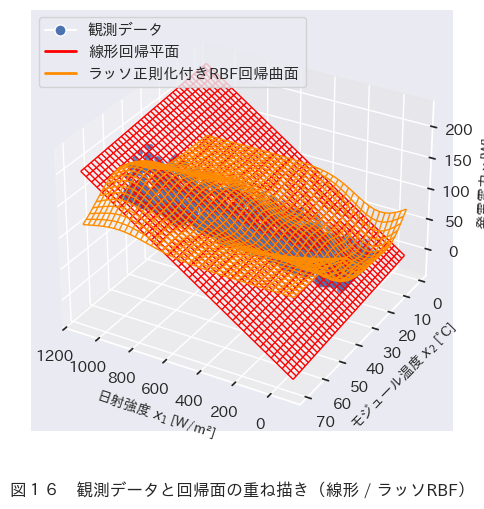

In [123]:
# 図１６: 観測データと回帰面の重ね描き（線形 / ラッソRBF）
yfit_lin_b = reg_lin.predict(Xfit).reshape(xfit1.shape)
yfit_lasso_b = regmp.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure(figsize=(8.0, 6.2))
ax = fig.add_subplot(111, projection='3d')

# 観測データと2モデルを同一軸上に重ねる
ax.scatter(x1, x2, y, s=10, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lin_b, color='red', linewidth=1.0)
ax.plot_wireframe(xfit1, xfit2, yfit_lasso_b, color='darkorange', linewidth=1.0)

ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.12, '図１６　観測データと回帰面の重ね描き（線形 / ラッソRBF）',
          transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=30, azim=120)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形回帰平面'),
    Line2D([0], [0], color='darkorange', lw=2, label='ラッソ正則化付きRBF回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')

plt.subplots_adjust(bottom=0.2)
plt.show()

## AIC最小モデル（基底展開重回帰）用 図（example01_02 と同型）

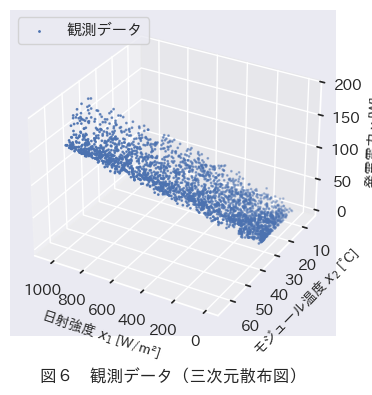

In [124]:
# 図６　観測データ（三次元散布図）
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.scatter(x1, x2, y, color='#4C72B0', s=1, label='観測データ')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図６　観測データ（三次元散布図）', transform=ax.transAxes, ha='center', va='top')

minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2
ax.set_xlim([minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1])
ax.set_ylim([minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2])

ax.view_init(elev=30, azim=120)
ax.grid(True)
ax.legend(loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()

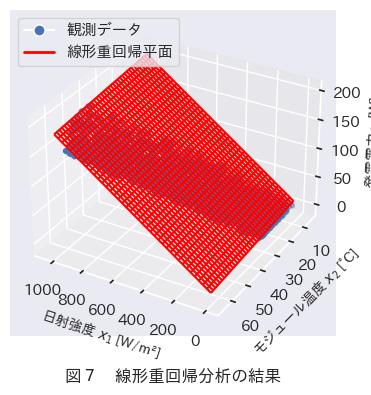

In [125]:
# 図７　線形重回帰分析の結果
nPoints = 40
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1, maxx1, nPoints),
    np.linspace(minx2, maxx2, nPoints)
)
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)

yfit_lin = reg_lin.predict(Xfit).reshape(xfit1.shape)

ax = plt.axes(projection='3d')
ax.scatter(x1, x2, y, color='#4C72B0', s=12)
ax.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図７　線形重回帰分析の結果', transform=ax.transAxes, ha='center', va='top')

ax.set_xlim([minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1])
ax.set_ylim([minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2])
ax.view_init(elev=30, azim=120)
ax.grid(True)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形重回帰平面'),
]
ax.legend(handles=legend_handles, loc='upper left')

plt.subplots_adjust(bottom=0.2)
plt.show()

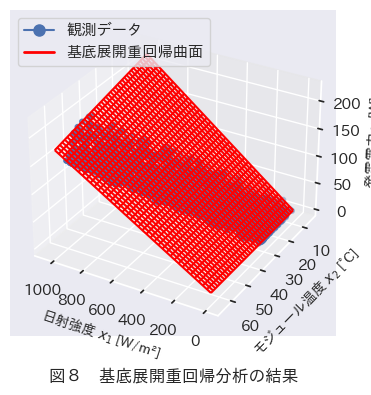

In [126]:
# 図８　基底展開重回帰分析の結果
nPoints = 40
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1, maxx1, nPoints),
    np.linspace(minx2, maxx2, nPoints)
)
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)

yfit_basis = reg_opt.predict(Xfit).reshape(xfit1.shape)

ax = plt.axes(projection='3d')
ax.scatter(x1, x2, y, color='#4C72B0', s=12)
ax.plot_wireframe(xfit1, xfit2, yfit_basis, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図８　基底展開重回帰分析の結果', transform=ax.transAxes, ha='center', va='top')

ax.set_xlim([minx1 - 0.1 * rx1, maxx1 + 0.1 * rx1])
ax.set_ylim([minx2 - 0.1 * rx2, maxx2 + 0.1 * rx2])
ax.view_init(elev=30, azim=120)
ax.grid(True)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='#4C72B0', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='基底展開重回帰曲面'),
]
ax.legend(handles=legend_handles, loc='upper left')

plt.subplots_adjust(bottom=0.2)
plt.show()

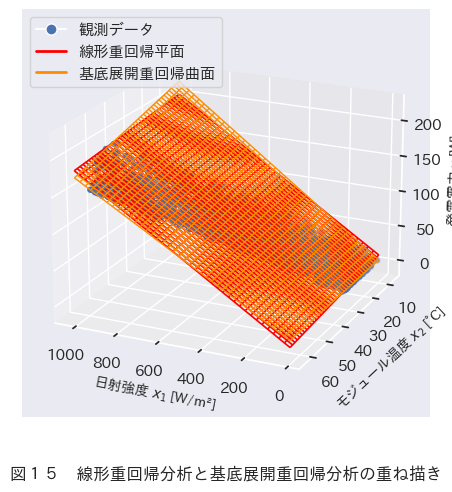

In [127]:
# 図１５　線形重回帰分析と基底展開重回帰分析の重ね描き
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

nPoints = 40
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()

xfit1, xfit2 = np.meshgrid(
    np.linspace(minx1, maxx1, nPoints),
    np.linspace(minx2, maxx2, nPoints)
)
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)

yfit_lin = reg_lin.predict(Xfit).reshape(xfit1.shape)
yfit_basis = reg_opt.predict(Xfit).reshape(xfit1.shape)

ax.scatter(x1, x2, y, color='#4C72B0', s=12, label='観測データ')
ax.plot_wireframe(xfit1, xfit2, yfit_lin, color='red', linewidth=1.2)
ax.plot_wireframe(xfit1, xfit2, yfit_basis, color='darkorange', linewidth=1.0)

ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.12, '図１５　線形重回帰分析と基底展開重回帰分析の重ね描き',
          transform=ax.transAxes, ha='center', va='top')

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形重回帰平面'),
    Line2D([0], [0], color='darkorange', lw=2, label='基底展開重回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')

ax.view_init(elev=20, azim=115)
plt.subplots_adjust(bottom=0.2)
plt.show()

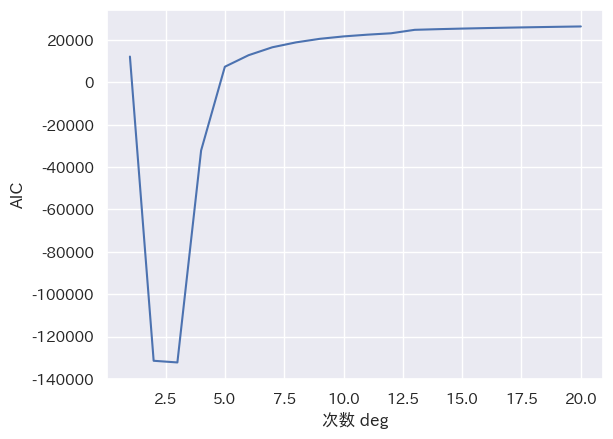

In [128]:
# AICのプロット（基底展開次数ごとの比較）
fig, ax = plt.subplots()
ax.plot(deg_list, aic_list)
ax.set_xlabel('次数 deg')
ax.set_ylabel('AIC')
ax.grid(True)
plt.show()